In [1]:
import pandas as pd
import numpy as np

# File paths
file1 = "../../../data/streamflow/gauge_flow/q_obs_PMET.csv"
file2 = "../../../data/streamflow/gauge_flow/raw_DGA_daily_post_PMET/observed gauge flow - all rivers avg.csv"
output_file = "../../../data/streamflow/gauge_flow/compiled_gauge_flow_raw/compiled_gauge_flow_raw.csv"

# River names and corresponding codes
rivers = {
    "Aysen": "X11342001",
    "Cisnes": "X11147001",
    "Palena": "X11040001",
    "Puelo": "X10523002",
    "Yelcho": "X10704002"
}

# Read the CSV files
df1 = pd.read_csv(file1, parse_dates=['Date'])
df2 = pd.read_csv(file2, parse_dates=['Date'])

# Function to ensure date columns are parsed correctly
def parse_dates(df, date_col):
    if df[date_col].dtype == 'object':
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    return df

df1 = parse_dates(df1, 'Date')
df2 = parse_dates(df2, 'Date')

# Create a dictionary to hold the combined data
combined_data = {'Date': pd.Series([])}

# Initialize combined_data dictionary with river columns
for river in rivers.keys():
    combined_data[river] = pd.Series([])

# Process each river
for river, code in rivers.items():
    # Merge the two dataframes on the 'Date' column
    df_merged = pd.merge(df1[['Date', code]], df2[['Date', river]], on='Date', how='outer')
    
    # Debug: Print column names after merge
    print(f"Column names after merging for {river}: {df_merged.columns.tolist()}")
    
    # Handle cases where suffixes are not applied
    if f"{code}" in df_merged.columns and f"{river}" in df_merged.columns:
        file1_col = f"{code}"
        file2_col = f"{river}"
    else:
        file1_col = f"{code}_file1"
        file2_col = f"{river}_file2"

    # Check for mismatched duplicate dates
    mismatches = df_merged[(df_merged[file1_col].notna()) & (df_merged[file2_col].notna()) & (df_merged[file1_col] != df_merged[file2_col])]
    
    # Print mismatches if any
    if not mismatches.empty:
        print(f"Mismatches for {river}:")
        print(mismatches[['Date', file1_col, file2_col]])
        print()
    
    # Fill NaN values with data from the other file
    df_merged[river] = df_merged[file1_col].combine_first(df_merged[file2_col])
    
    # Add combined data to the combined_data dictionary
    combined_data['Date'] = df_merged['Date']
    combined_data[river] = df_merged[river]

# Create a DataFrame from the combined data dictionary
df_combined = pd.DataFrame(combined_data)

# Save the combined DataFrame to a CSV file
df_combined.to_csv(output_file, index=False)

print(f"Combined streamflow data saved to {output_file}")


/var/folders/x8/mpvljg_94_nb_bqxjncltssw0000gn/T/ipykernel_341/1461662466.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1 = pd.read_csv(file1, parse_dates=['Date'])


Column names after merging for Aysen: ['Date', 'X11342001', 'Aysen']
Column names after merging for Cisnes: ['Date', 'X11147001', 'Cisnes']
Column names after merging for Palena: ['Date', 'X11040001', 'Palena']
Column names after merging for Puelo: ['Date', 'X10523002', 'Puelo']
Column names after merging for Yelcho: ['Date', 'X10704002', 'Yelcho']
Combined streamflow data saved to ../../../data/streamflow/gauge_flow/compiled_gauge_flow_raw/compiled_gauge_flow_raw.csv



Analysis for Aysen:



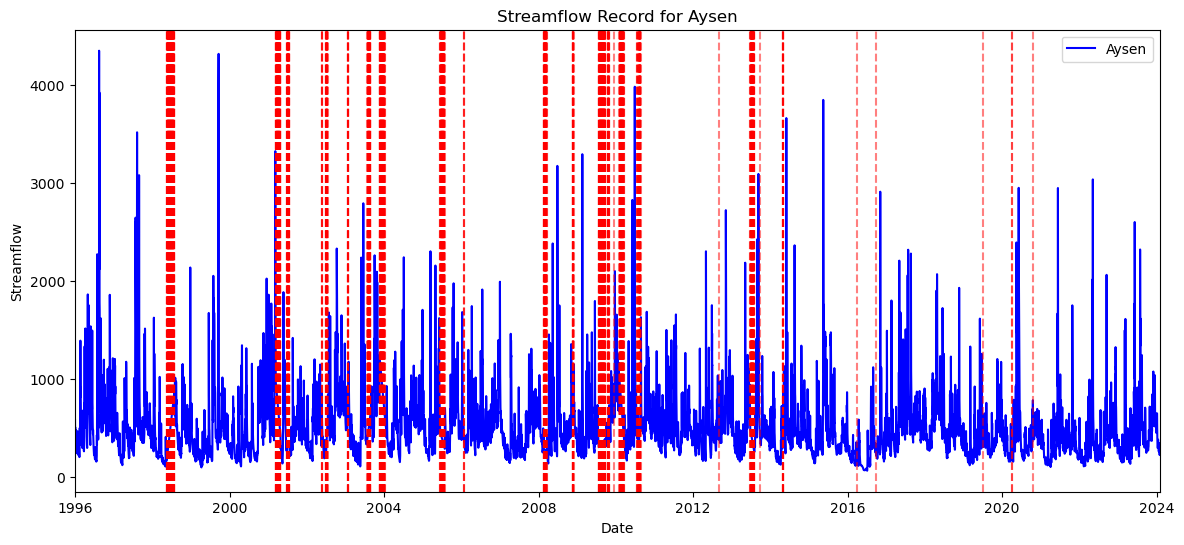

Streamflow Summary:
  First Date  Last Date  Number of Gaps  Mean Streamflow  \
0 1995-12-30 2024-01-31              30       507.996168   

   Standard Deviation Streamflow  Minimum Streamflow  
0                     343.887523                67.3  

Repeated Values Summary:
  Start_Date   End_Date  Duration  Value
0 1996-01-16 1996-01-17         2  264.0
1 2007-07-10 2007-07-11         2  218.0

Gap Summary:
   Start Date   End Date  Duration
0  1998-05-19 1998-07-27        69
1  2001-03-14 2001-04-26        43
2  2001-06-28 2001-07-18        20
3  2002-05-25 2002-05-28         3
4  2002-07-01 2002-07-16        15
5  2003-01-25 2003-01-30         5
6  2003-07-28 2003-08-25        28
7  2003-11-20 2004-01-07        48
8  2005-06-16 2005-07-26        40
9  2006-01-24 2006-01-26         2
10 2008-02-20 2008-03-18        27
11 2008-11-18 2008-11-27         9
12 2009-07-24 2009-09-23        61
13 2009-10-17 2009-10-28        11
14 2009-12-17 2009-12-17         0
15 2010-02-04 2010-03-17  

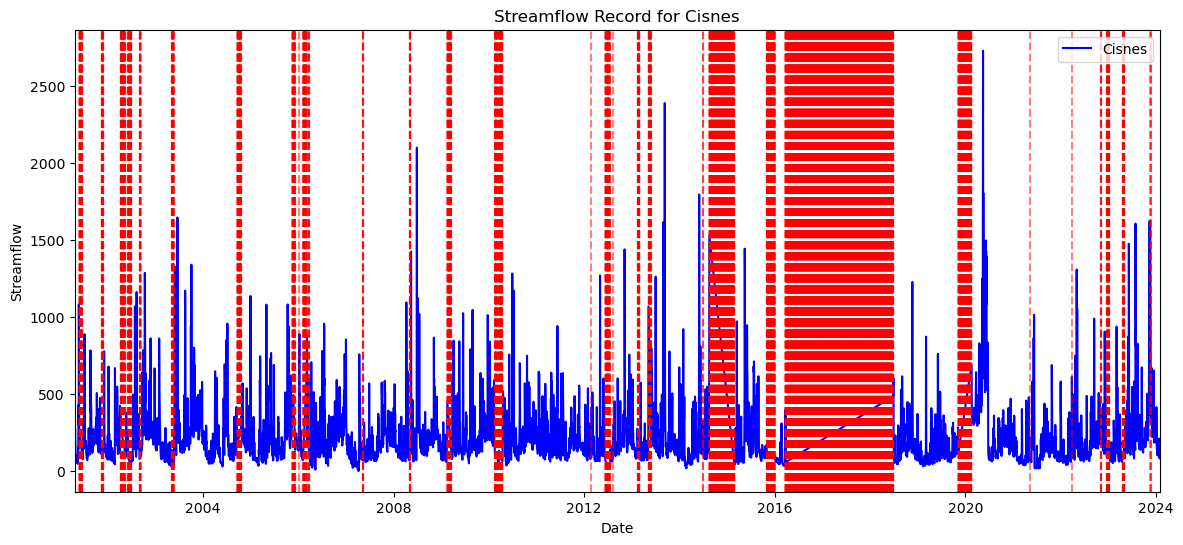

Streamflow Summary:
  First Date  Last Date  Number of Gaps  Mean Streamflow  \
0 2001-04-23 2024-01-31              41       215.629124   

   Standard Deviation Streamflow  Minimum Streamflow  
0                     195.235213                1.52  

Repeated Values Summary:
  Start_Date   End_Date  Duration     Value
0 2021-07-14 2021-07-15         2    17.417
1 2023-11-12 2023-11-19         8  1621.590

Gap Summary:
   Start Date   End Date  Duration
0  2001-05-29 2001-06-18        20
1  2001-11-15 2001-11-27        12
2  2002-04-09 2002-05-13        34
3  2002-06-05 2002-06-10         5
4  2002-06-16 2002-07-01        15
5  2002-09-03 2002-09-09         6
6  2003-05-08 2003-05-21        13
7  2004-09-21 2004-10-19        28
8  2005-11-17 2005-11-22         5
9  2005-11-24 2005-12-06        12
10 2006-01-03 2006-01-03         0
11 2006-02-08 2006-03-06        26
12 2006-03-24 2006-03-27         3
13 2007-05-08 2007-05-10         2
14 2007-05-12 2007-05-12         0
15 2008-05-03 200

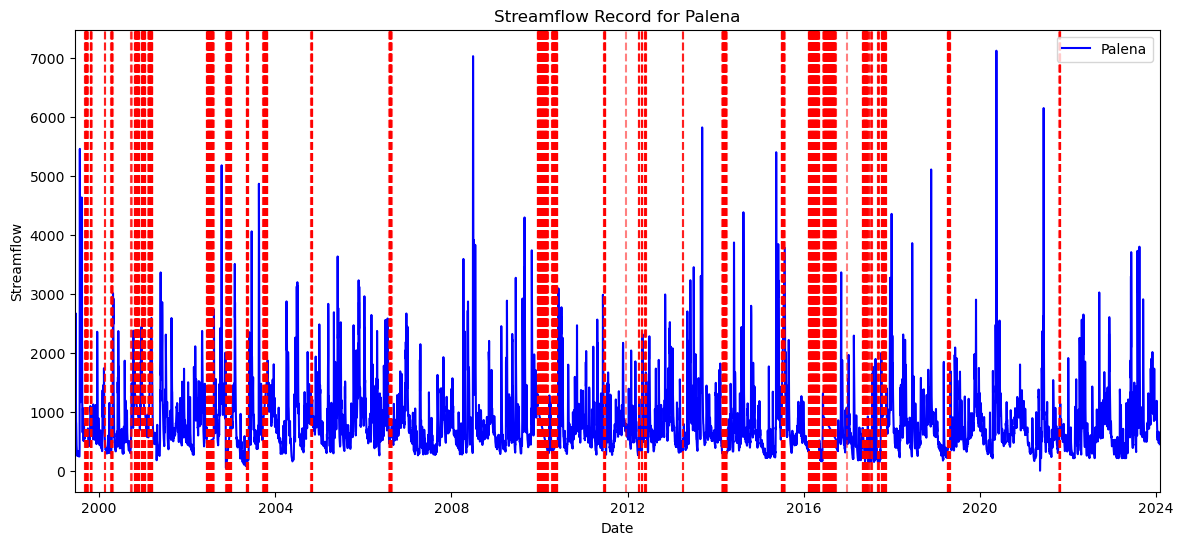

Streamflow Summary:
  First Date  Last Date  Number of Gaps  Mean Streamflow  \
0 1999-06-13 2024-01-31              44        814.23796   

   Standard Deviation Streamflow  Minimum Streamflow  
0                     567.186387                 0.0  

Repeated Values Summary:
   Start_Date   End_Date  Duration  Value
0  1999-07-17 1999-07-19         3  243.0
1  2000-03-07 2000-03-08         2  295.0
2  2002-11-18 2002-11-20         3   47.9
3  2004-05-25 2004-05-30         6  189.0
4  2005-04-27 2005-04-28         2  296.0
5  2007-04-01 2007-04-05         5  296.0
6  2007-06-03 2007-06-05         3  296.0
7  2007-08-20 2007-08-21         2  292.0
8  2008-03-13 2008-03-14         2  296.0
9  2008-04-01 2008-04-03         3  296.0
10 2013-04-28 2013-04-29         2  370.0
11 2014-04-03 2014-04-09         7  327.0
12 2015-02-20 2015-02-28         9  217.0
13 2016-05-26 2016-05-28         3  160.0
14 2017-09-20 2017-09-21         2  151.0
15 2021-05-18 2021-05-22         5  213.9
16 2022-0

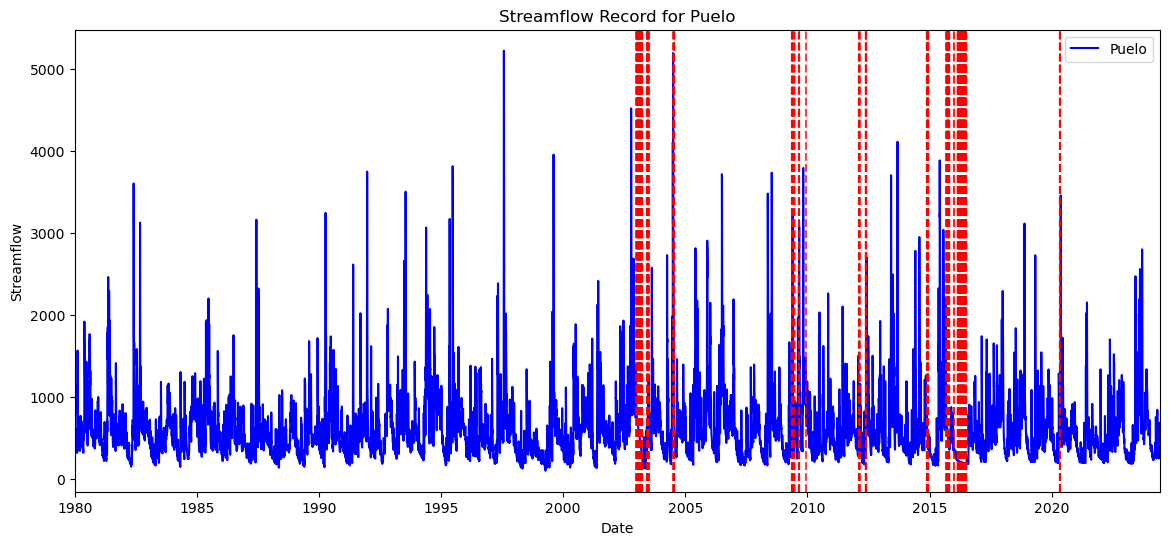

Streamflow Summary:
  First Date  Last Date  Number of Gaps  Mean Streamflow  \
0 1980-01-01 2024-06-06              20       605.563887   

   Standard Deviation Streamflow  Minimum Streamflow  
0                     408.518117               102.0  

Repeated Values Summary:
   Start_Date   End_Date  Duration    Value
0  1987-02-12 1987-02-13         2  262.000
1  1988-10-03 1988-10-04         2  360.000
2  1992-01-21 1992-01-22         2  393.000
3  1993-12-23 1993-12-25         3  670.000
4  2000-05-06 2000-05-07         2  339.000
5  2009-10-19 2009-10-20         2  348.000
6  2012-05-14 2012-05-22         9  327.000
7  2012-08-19 2012-08-20         2  587.000
8  2016-07-02 2016-07-08         7  184.000
9  2016-07-25 2016-07-28         4  184.000
10 2017-02-13 2017-02-14         2  210.000
11 2019-03-18 2019-03-19         2  232.000
12 2019-03-28 2019-04-03         7  209.000
13 2019-04-07 2019-04-12         6  209.000
14 2020-04-09 2020-04-14         6  198.792
15 2021-03-23 2021-

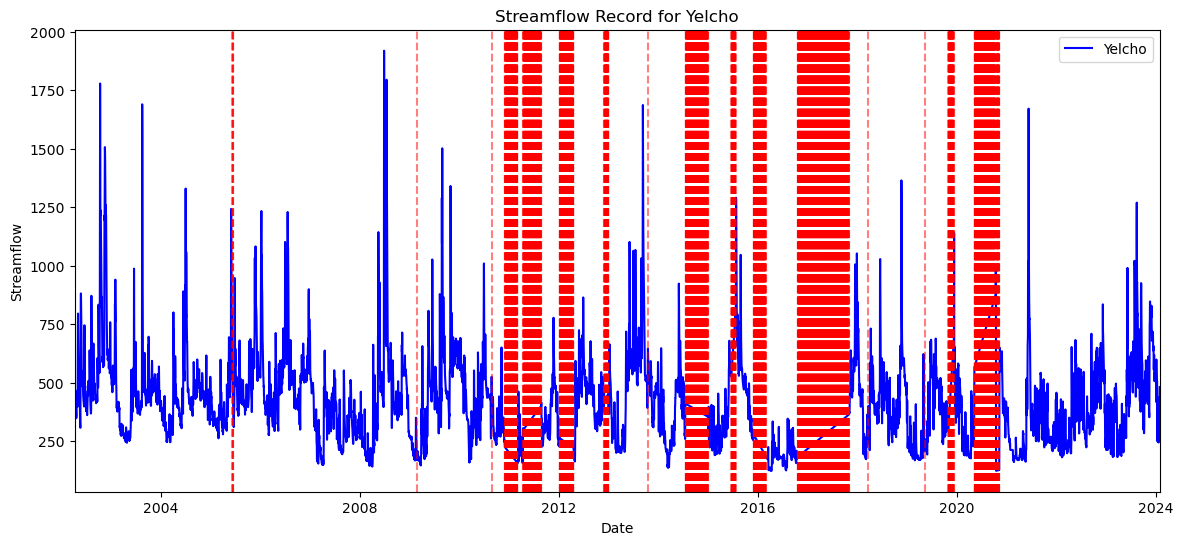

Streamflow Summary:
  First Date  Last Date  Number of Gaps  Mean Streamflow  \
0 2002-04-10 2024-01-31              21       421.041568   

   Standard Deviation Streamflow  Minimum Streamflow  
0                     192.343441              123.57  

Repeated Values Summary:
   Start_Date   End_Date  Duration    Value
0  2008-12-06 2008-12-07         2  534.000
1  2009-11-13 2009-11-14         2  525.000
2  2010-08-10 2010-08-11         2  439.000
3  2012-04-26 2012-04-27         2  169.000
4  2012-08-02 2012-08-05         4  486.000
5  2013-02-23 2013-02-24         2  216.000
6  2016-04-05 2016-04-06         2  124.000
7  2016-04-11 2016-04-13         3  124.000
8  2016-06-19 2016-06-21         3  177.000
9  2019-04-01 2019-04-04         4  172.000
10 2020-10-17 2020-10-19         3  123.570
11 2021-01-30 2021-02-02         4  212.256
12 2021-02-12 2021-02-16         5  212.256

Gap Summary:
   Start Date   End Date  Duration
0  2005-06-10 2005-06-10         0
1  2005-06-16 2005-06-1

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

# Ensure the output directory exists
output_dir = "../../../data/streamflow/gauge_flow/compiled_gauge_flow_raw/quality_control_stats"
os.makedirs(output_dir, exist_ok=True)

# Load the combined data
combined_data = pd.read_csv("../../../data/streamflow/gauge_flow/compiled_gauge_flow_raw/compiled_gauge_flow_raw.csv", parse_dates=['Date'])

# Function to plot streamflow and highlight gaps
def plot_streamflow_with_gaps(data, river_name):
    river_data = data[['Date', river_name]].dropna()
    plt.figure(figsize=(14, 6))
    plt.plot(river_data['Date'], river_data[river_name], label=river_name, color='blue')
    # Highlight gaps with vertical red bands
    gaps = data['Date'][data[river_name].isna() & (data['Date'] >= river_data['Date'].min()) & (data['Date'] <= river_data['Date'].max())]
    for gap in gaps:
        plt.axvline(x=gap, color='red', linestyle='--', alpha=0.5)
    plt.xlim(river_data['Date'].min(), river_data['Date'].max())
    plt.xlabel('Date')
    plt.ylabel('Streamflow')
    plt.title(f'Streamflow Record for {river_name}')
    plt.legend()
    plt.savefig(f"{output_dir}/{river_name}_streamflow_plot.png")
    plt.show()  # Display the plot in the notebook

# Function to summarize streamflow data
def summarize_streamflow(data, river_name):
    summary = {}
    summary['First Date'] = data['Date'][data[river_name].notna()].min()
    summary['Last Date'] = data['Date'][data[river_name].notna()].max()
    summary['Number of Gaps'] = ((data[river_name].isna().astype(int).groupby(data[river_name].notna().astype(int).cumsum()).sum() > 0).sum())
    summary['Mean Streamflow'] = data[river_name].mean()
    summary['Standard Deviation Streamflow'] = data[river_name].std()
    summary['Minimum Streamflow'] = data[river_name].min()
    return summary

# Function to identify sequential repeated values
def identify_repeated_values(data, river_name):
    data['Repeated'] = (data[river_name] == data[river_name].shift())
    repeated_groups = data.groupby((data['Repeated'] != data['Repeated'].shift()).cumsum())
    
    repeated_summary_list = []

    for name, group in repeated_groups:
        if group['Repeated'].all() and len(group) > 1:  # Ensure we have a repeated group of more than one
            repeated_summary_list.append({
                'Start_Date': group['Date'].iloc[0],
                'End_Date': group['Date'].iloc[-1],
                'Duration': len(group),
                'Value': group[river_name].iloc[0]
            })

    repeated_summary = pd.DataFrame(repeated_summary_list)
    
    return repeated_summary

# Function to summarize gaps in the data
def summarize_gaps(data, river_name):
    first_date = data['Date'][data[river_name].notna()].min()
    last_date = data['Date'][data[river_name].notna()].max()
    data_within_range = data[(data['Date'] >= first_date) & (data['Date'] <= last_date)].copy()
    data_within_range.loc[:, 'Gap'] = data_within_range[river_name].isna()
    data_within_range.loc[:, 'GapGroup'] = (data_within_range['Gap'] != data_within_range['Gap'].shift()).cumsum()
    gap_summary = data_within_range[data_within_range['Gap']].groupby('GapGroup').agg({'Date': ['first', 'last'], 'Gap': 'size'})
    gap_summary.columns = ['Start Date', 'End Date', 'Duration']
    gap_summary = gap_summary.reset_index(drop=True)
    gap_summary['Duration'] = gap_summary['Duration'] - 1  # Subtract 1 to get the duration in days
    return gap_summary

# Analyze each river
rivers = combined_data.columns[1:]  # Exclude the 'Date' column

for river in rivers:
    print(f"\nAnalysis for {river}:\n")
    
    # Plot streamflow with gaps
    plot_streamflow_with_gaps(combined_data, river)
    
    # Summarize streamflow data
    summary = summarize_streamflow(combined_data, river)
    summary_df = pd.DataFrame([summary])
    print("Streamflow Summary:")
    print(summary_df)
    summary_df.to_csv(f"{output_dir}/{river}_streamflow_summary.csv", index=False)
    
    # Identify repeated values
    repeated_values_summary = identify_repeated_values(combined_data, river)
    if not repeated_values_summary.empty:
        print("\nRepeated Values Summary:")
        print(repeated_values_summary)
        repeated_values_summary.to_csv(f"{output_dir}/{river}_repeated_values_summary.csv", index=False)
    else:
        print("\nNo repeated values found.")
    
    # Summarize gaps in the data
    gap_summary = summarize_gaps(combined_data, river)
    if not gap_summary.empty:
        print("\nGap Summary:")
        print(gap_summary)
        gap_summary.to_csv(f"{output_dir}/{river}_gap_summary.csv", index=False)
    else:
        print("\nNo gaps found.")
